<a href="https://colab.research.google.com/github/Enrik-Shabani/ML-Project-GroupA/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Beijing Air Quality Analysis - Part 1: Data Exploration

**Project Goal:** Predict PM2.5 pollution levels and identify urban pollution patterns

**This Notebook:**
- Load and clean Beijing air quality dataset
- Exploratory data analysis (EDA)
- Time-series visualization
- Correlation analysis

**Dataset:** Beijing Multi-Site Air-Quality Data (2013-2017)

Importing the necessary libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

base = "https://raw.githubusercontent.com/Enrik-Shabani/ML-Project-GroupA/main/data/"

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data Loading
This section loads and merges the 12 Beijing air-quality station datasets into a single dataframe.

In [ ]:
df1 = pd.read_csv(base + "PRSA_Data_Aotizhongxin_20130301-20170228.csv")
df2 = pd.read_csv(base + "PRSA_Data_Changping_20130301-20170228.csv")
df3 = pd.read_csv(base + "PRSA_Data_Dingling_20130301-20170228.csv")
df4 = pd.read_csv(base + "PRSA_Data_Dongsi_20130301-20170228.csv")
df5 = pd.read_csv(base + "PRSA_Data_Guanyuan_20130301-20170228.csv")
df6 = pd.read_csv(base + "PRSA_Data_Gucheng_20130301-20170228.csv")
df7 = pd.read_csv(base + "PRSA_Data_Huairou_20130301-20170228.csv")
df8 = pd.read_csv(base + "PRSA_Data_Nongzhanguan_20130301-20170228.csv")
df9 = pd.read_csv(base + "PRSA_Data_Shunyi_20130301-20170228.csv")
df10 = pd.read_csv(base + "PRSA_Data_Tiantan_20130301-20170228.csv")
df11 = pd.read_csv(base + "PRSA_Data_Wanliu_20130301-20170228.csv")
df12 = pd.read_csv(base + "PRSA_Data_Wanshouxigong_20130301-20170228.csv")

In [13]:
df = pd.concat(
    [df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12],
    ignore_index=True
)

print("Shape:", df.shape)
df.head()

Shape: (420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [14]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


In [15]:
df["datetime"] = pd.to_datetime(df[["year","month","day","hour"]])
df = df.sort_values(["station","datetime"])

In [16]:
station_mean = df.groupby("station")["PM2.5"].mean().sort_values()
station_mean

,PM2.5
station,
Dingling,65.989497
Huairou,69.626367
Changping,71.099743
Shunyi,79.491602
Tiantan,82.164911
Aotizhongxin,82.773611
Guanyuan,82.933372
Wanliu,83.374716
Gucheng,83.852089


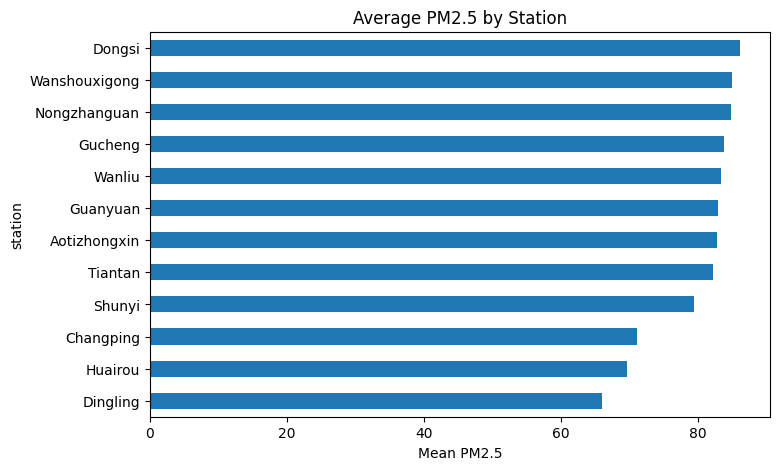

In [17]:
plt.figure(figsize=(8,5))
station_mean.plot(kind="barh")
plt.title("Average PM2.5 by Station")
plt.xlabel("Mean PM2.5")
plt.show()

## Temporal Patterns Analysis

Air pollution levels often vary over time due to seasonal changes, meteorological conditions, and human activities, and seasonal effects.

To better understand these temporal dynamics, we analyze PM2.5 patterns at three different time scales:

- monthly (seasonal variation)
- hourly (daily pollution cycles)
- yearly (long-term trends).

 These analyses help reveal seasonal cycles, daily pollution peaks, and long-term changes in air quality.

### Hourly PM2.5 Pattern
To analyze short-term temporal dynamics in air pollution, we compute the average PM2.5 concentration for each hour of the day.
This visualization helps identify recurring daily pollution cycles that may be associated with human activities such as traffic peaks, industrial operations, and changes in atmospheric dispersion conditions.

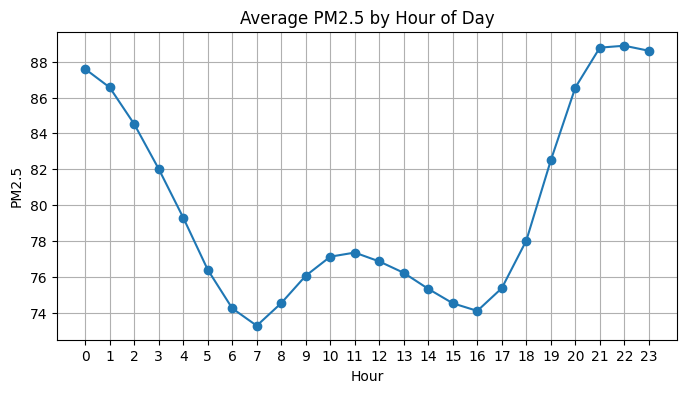

In [18]:
hourly_pm25 = df.groupby("hour")["PM2.5"].mean()

plt.figure(figsize=(8,4))
plt.plot(hourly_pm25.index, hourly_pm25.values, marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5")
plt.grid(True)
plt.xticks(range(0,24))
plt.show()

### Daily PM2.5 Pattern
Air pollution levels can vary throughout the day due to human activities such as traffic, industrial operations, and atmospheric conditions.
To investigate these daily dynamics, we compute the average PM2.5 concentration for each hour of the day. This visualization helps identify recurring daily pollution peaks and periods of lower air pollution.

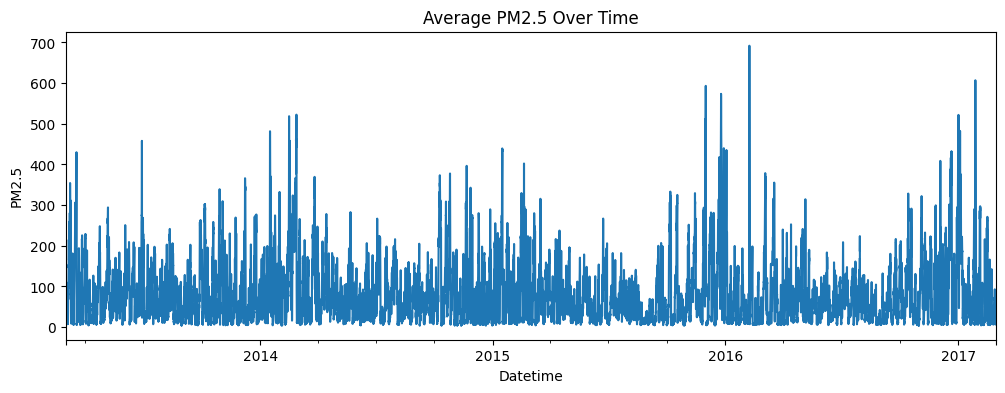

In [19]:
daily_pm25 = df.groupby("datetime")["PM2.5"].mean()

plt.figure(figsize=(12,4))
daily_pm25.plot()
plt.title("Average PM2.5 Over Time")
plt.xlabel("Datetime")
plt.ylabel("PM2.5")
plt.show()

### Monthly PM2.5 Pattern
To explore seasonal variations in air pollution, we compute the average PM2.5 concentration for each month.
Seasonal patterns are important because air pollution levels often change throughout the year due to factors such as heating during winter, meteorological conditions, and atmospheric dispersion. This visualization helps identify months with systematically higher or lower pollution levels.

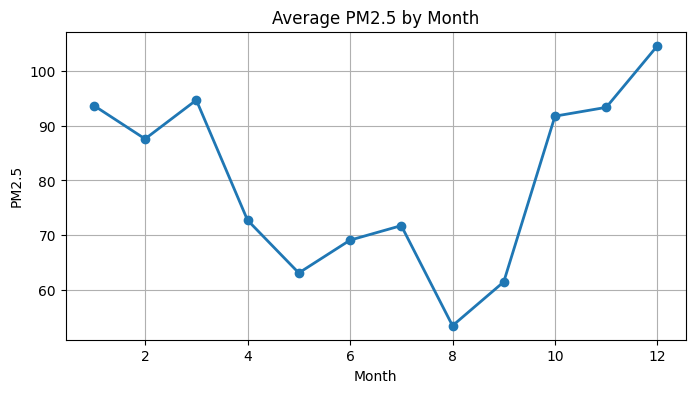

In [20]:
month_order = [1,2,3,4,5,6,7,8,9,10,11,12]
monthly_pm25 = df.groupby("month")["PM2.5"].mean().reindex(month_order)

plt.figure(figsize=(8,4))
monthly_pm25.plot(marker="o", linewidth=2)
plt.title("Average PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("PM2.5")
plt.grid(True)
plt.show()

The plot suggests a clear seasonal pattern in PM2.5 concentrations. Pollution levels tend to be higher during winter months, which may be related to heating activities and unfavorable atmospheric dispersion conditions. Lower levels are generally observed during summer.

### Yearly PM2.5 Pattern
To understand the long-term evolution of air pollution in Beijing, we examine the average PM2.5 concentration by year.
This visualization helps identify whether pollution levels improved or worsened over time during the observation period (2013–2017). Such analysis can reveal the potential impact of environmental policies, urban development, or changes in industrial activity on air quality.

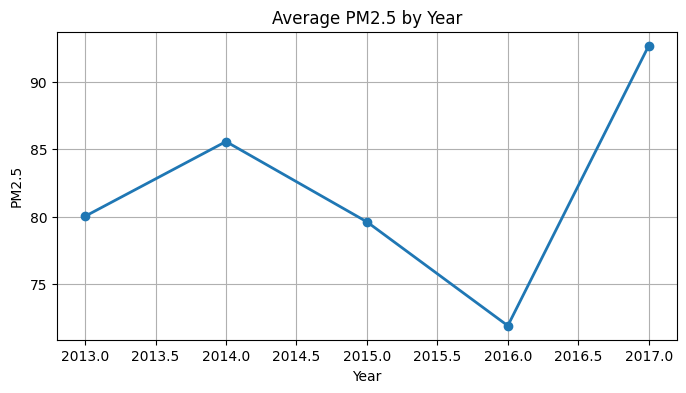

In [21]:
yearly_pm25 = df.groupby("year")["PM2.5"].mean()

plt.figure(figsize=(8,4))
yearly_pm25.plot(marker="o", linewidth=2)
plt.title("Average PM2.5 by Year")
plt.xlabel("Year")
plt.ylabel("PM2.5")
plt.grid(True)
plt.show()

In [22]:
df[["station", "datetime"]].head()

,station,datetime
0,Aotizhongxin,2013-03-01 00:00:00
1,Aotizhongxin,2013-03-01 01:00:00
2,Aotizhongxin,2013-03-01 02:00:00
3,Aotizhongxin,2013-03-01 03:00:00
4,Aotizhongxin,2013-03-01 04:00:00


## Data preprocessing
### Missing values analysis
Before modeling, missing values must be identified and handled appropriately. Since this is a multi-station time-series dataset, imputation strategies must preserve temporal continuity within each station while avoiding unrealistic distortions.

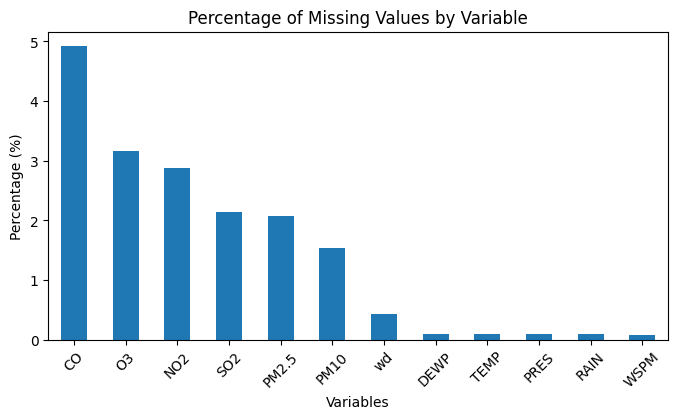

In [23]:
missing_percentage = (df.isna().mean() * 100).sort_values(ascending=False)
missing_percentage[missing_percentage > 0].plot(kind="bar", figsize=(8,4))
plt.title("Percentage of Missing Values by Variable")
plt.ylabel("Percentage (%)")
plt.xlabel("Variables")
plt.xticks(rotation=45)
plt.show()

In [24]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

,0
CO,20701
O3,13277
NO2,12116
SO2,9021
PM2.5,8739
PM10,6449
wd,1822
DEWP,403
TEMP,398
PRES,393


## Exploratory Data Analysis (EDA)
This section explores the structure and statistical properties of the Beijing multi-site air-quality dataset. The objective is to understand the distribution of the target variable (PM2.5), identify missing values and outliers, compare pollution levels across stations and time, and examine relationships between pollutants and meteorological variables before feature engineering and model training.

In [25]:
missing_percentage = ((df.isna().sum() / len(df)) * 100).round(2)
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

,0
CO,4.92
O3,3.16
NO2,2.88
SO2,2.14
PM2.5,2.08
PM10,1.53
wd,0.43
DEWP,0.10
PRES,0.09
TEMP,0.09


### Distribution and outlier inspection

Air pollution datasets frequently contain extreme values corresponding to severe pollution events. Examining the distribution and potential outliers helps distinguish between genuine environmental events and possible measurement issues.

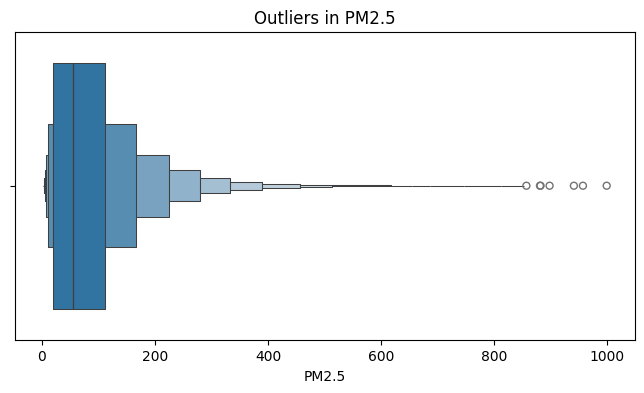

In [26]:
plt.figure(figsize=(8,4))
sns.boxenplot(x=df["PM2.5"])
plt.title("Outliers in PM2.5")
plt.show()

In [27]:
pollutants = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]

for col in pollutants:
    df[col] = df.groupby("station")[col].transform(lambda s: s.interpolate())

    weather = ["TEMP","PRES","DEWP","RAIN","WSPM"]

for col in weather:
    df[col] = df[col].fillna(df[col].median())

    df["wd"] = df["wd"].fillna(df["wd"].mode()[0])

missing_after = df.isna().sum()
missing_after[missing_after > 0].sort_values(ascending=False)

,0
NO2,22


Missing values were handled according to the variable type. Pollutant concentrations were imputed using interpolation within each station in order to preserve temporal continuity. Meteorological variables were imputed using the median to reduce the influence of extreme values. Missing values in wind direction were replaced with the mode.

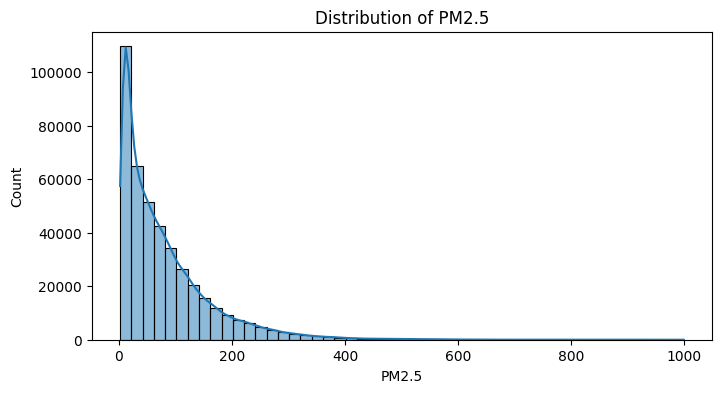

In [28]:
plt.figure(figsize=(8,4))
sns.histplot(df["PM2.5"], bins=50, kde=True)
plt.title("Distribution of PM2.5")
plt.show()

### Target variable exploration PM2.5
The skewness value is positive, indicating that the PM2.5 distribution is right-skewed, PM2.5 is the main target variable of this study. Understanding its distribution is important because air pollution data often exhibit skewness and extreme pollution events. Exploring the distribution helps determine whether transformations or robust modeling techniques may be required.

In [29]:
print("PM2.5 skewness:", df["PM2.5"].skew())

PM2.5 skewness: 2.020293255412701


In [30]:
df['log_PM25'] = np.log1p(df['PM2.5'])

Due to the positive skewness of PM2.5 values, a logarithmic transformation was applied to reduce the influence of extreme pollution values and obtain a more balanced distribution.

In [32]:
print("PM2.5 skewness:", df["PM2.5"].skew())
print("log_PM25 skewness:", df["log_PM25"].skew())

PM2.5 skewness: 2.020293255412701
log_PM25 skewness: -0.3121753279745473


The logarithmic transformation reduced the asymmetry of the PM2.5 distribution and produced a more balanced variable for further analysis.

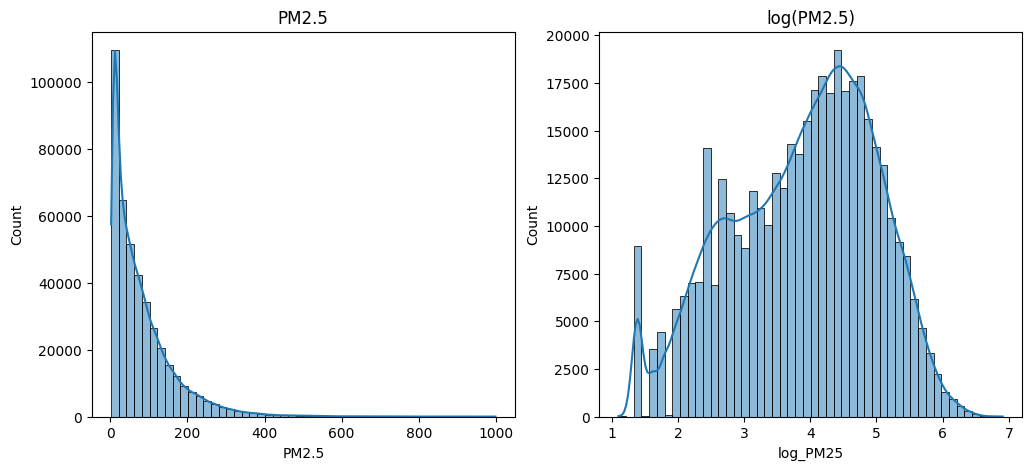

In [33]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["PM2.5"], bins=50, kde=True)
plt.title("PM2.5")

plt.subplot(1,2,2)
sns.histplot(df["log_PM25"], bins=50, kde=True)
plt.title("log(PM2.5)")

plt.show()

Figure X compares the distribution of PM2.5 before and after the logarithmic transformation. The transformed variable appears more balanced and less influenced by extreme pollution values.

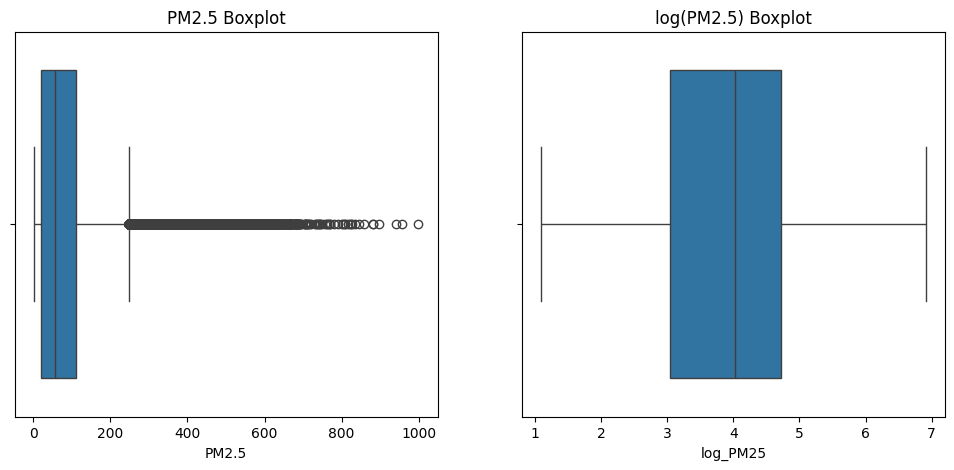

In [34]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df["PM2.5"])
plt.title("PM2.5 Boxplot")

plt.subplot(1,2,2)
sns.boxplot(x=df["log_PM25"])
plt.title("log(PM2.5) Boxplot")

plt.show()

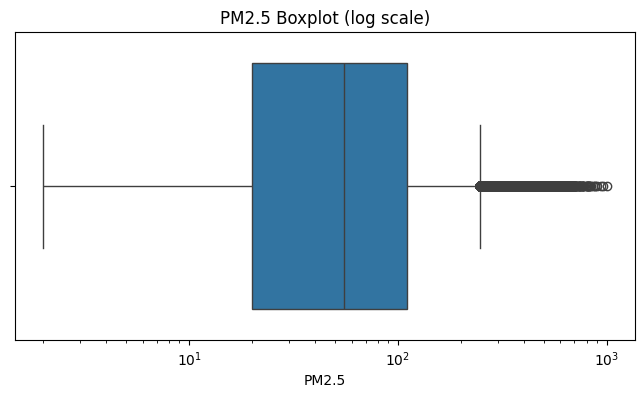

In [35]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["PM2.5"])
plt.xscale("log")
plt.title("PM2.5 Boxplot (log scale)")
plt.show()


### Outlier Analysis
The boxplot reveals the presence of extreme values in the PM2.5 distribution.
These high concentrations likely correspond to severe pollution episodes rather than measurement errors, which are common in air quality datasets.
Therefore, these observations are retained for the analysis as they represent real environmental conditions.

In [36]:
df['log_PM25'].describe()

,log_PM25
count,420768.000000
mean,3.884033
std,1.091435
min,1.098612
25%,3.044522
50%,4.025352
75%,4.718499
max,6.907755


### Spatial analysis across monitoring stations
Air pollution levels may differ across monitoring sites due to differences in traffic density, industrial activity, and urban structure. Comparing average PM2.5 levels across stations helps identify spatial heterogeneity in pollution exposure.


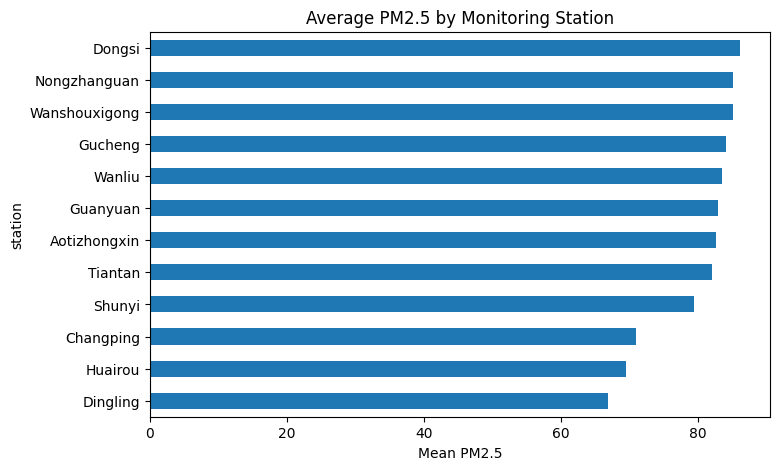

In [37]:
station_mean = df.groupby("station")["PM2.5"].mean().sort_values()

plt.figure(figsize=(8,5))
station_mean.plot(kind="barh")
plt.title("Average PM2.5 by Monitoring Station")
plt.xlabel("Mean PM2.5")
plt.show()

### Correlation analysis
The correlation matrix provides an overview of the relationships between PM2.5 and other pollutants or meteorological variables. This step helps identify variables that may be relevant predictors for pollution forecasting models.

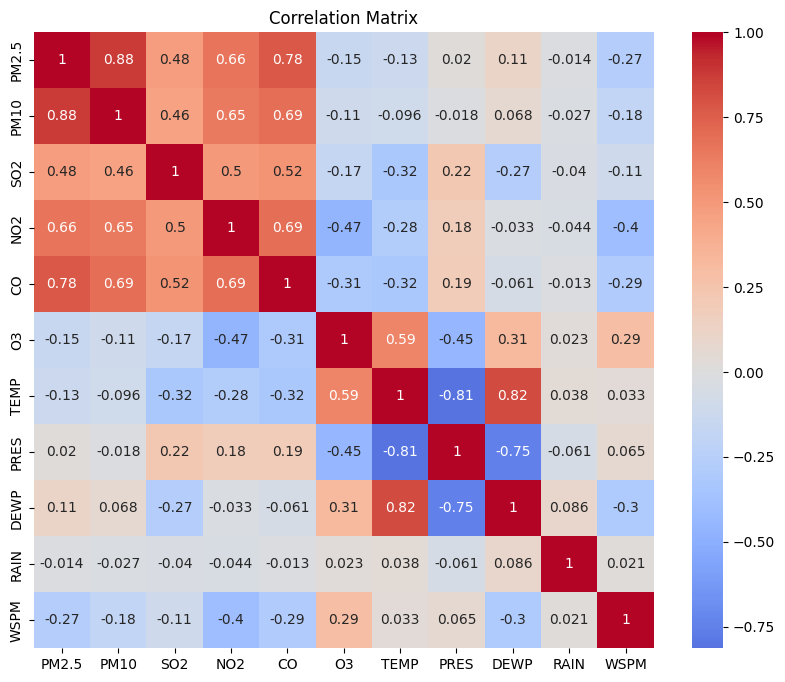

In [38]:
corr_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
corr = df[corr_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [39]:
corr_target = corr["PM2.5"].sort_values(ascending=False)
corr_target

,PM2.5
PM2.5,1.000000
PM10,0.878874
CO,0.780165
NO2,0.664300
SO2,0.478223
DEWP,0.112685
PRES,0.020142
RAIN,-0.014450
TEMP,-0.131929
O3,-0.149508


In [40]:
corr["PM2.5"].sort_values(ascending=False)

,PM2.5
PM2.5,1.000000
PM10,0.878874
CO,0.780165
NO2,0.664300
SO2,0.478223
DEWP,0.112685
PRES,0.020142
RAIN,-0.014450
TEMP,-0.131929
O3,-0.149508


The correlation analysis shows strong positive relationships between PM2.5 and other air pollutants such as PM10, CO, and NO2. Meteorological variables such as wind speed show negative correlations, indicating their role in dispersing pollutants.

In [41]:
top10 = (
    df.drop(columns=["log_PM25"], errors="ignore")
      .corr(numeric_only=True)["PM2.5"]
      .abs()
      .sort_values(ascending=False)[1:11]
)

print("Top 10 correlated features:")
print(top10)

Top 10 correlated features:
PM10    0.878874
CO      0.780165
NO2     0.664300
SO2     0.478223
WSPM    0.271416
O3      0.149508
TEMP    0.131929
DEWP    0.112685
year    0.026070
No      0.024719
Name: PM2.5, dtype: float64


### Top correlated features
To summarize the correlation analysis, the following ranking highlights the variables most strongly associated with PM2.5. These relationships provide a first indication of potential predictors for machine learning models.

In [42]:
df = df.sort_values(["station", "datetime"]).copy()

df["PM2.5_lag1"] = df.groupby("station")["PM2.5"].shift(1)
df["PM2.5_lag24"] = df.groupby("station")["PM2.5"].shift(24)
df["PM2.5_roll24"] = df.groupby("station")["PM2.5"].transform(lambda s: s.rolling(24).mean())

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

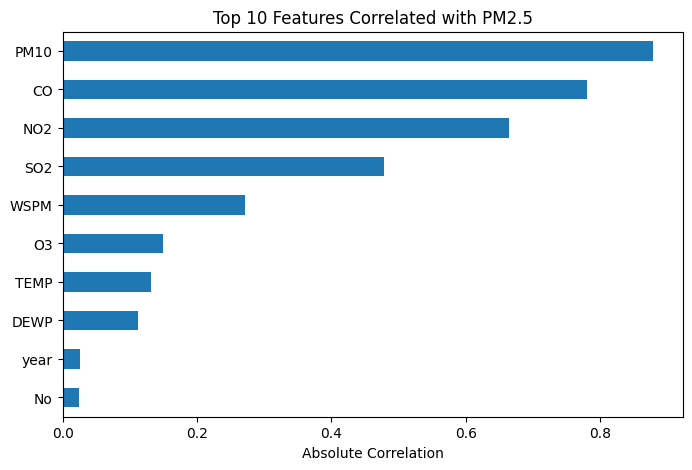

In [43]:
plt.figure(figsize=(8,5))
top10.sort_values().plot(kind="barh")
plt.title("Top 10 Features Correlated with PM2.5")
plt.xlabel("Absolute Correlation")
plt.show()

Overall, the EDA shows that PM2.5 is characterized by strong temporal persistence, substantial variation across stations, and clear relationships with both co-pollutants and weather conditions. These findings justify the inclusion of pollutant, meteorological, and engineered temporal variables in the predictive modeling stage